# Exp 1 - Simple Perceptron

Weights: [ 2.4 -2.4] 
Bias: 0.30000000000000004


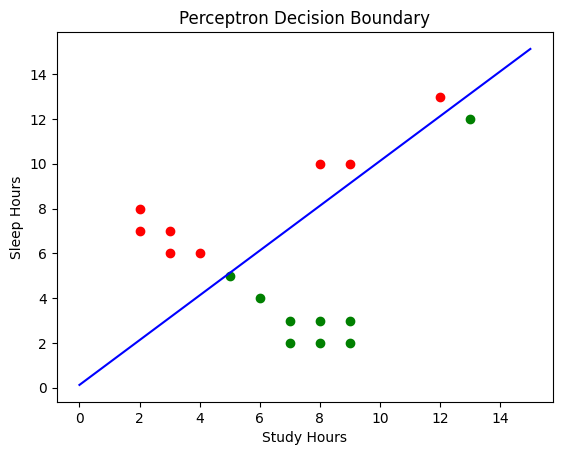

Predictions: [1, 1]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [2,7],[3,6],[4,6],[2,8],[8,10],[9,10],[12,13],[3,7],
    [7,3],[8,2],[9,3],[6,4],[5,5],[7,2],[8,3],[9,2],[13,12]
])
y = np.array([0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1])

# Perceptron Training
w = np.zeros(2)
b = 0
lr = 0.1
epochs = 20

def step(z): return 1 if z>=0 else 0

for _ in range(epochs):
    for i in range(len(X)):
        y_pred = step(np.dot(X[i],w)+b)
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

print("Weights:",w,"\nBias:",b)

# Plot decision boundary
for i in range(len(X)):
    plt.scatter(X[i][0],X[i][1],c='green' if y[i]==1 else 'red')

x1 = np.linspace(0,15,100)
x2 = -(w[0]*x1 + b)/w[1]
plt.plot(x1,x2,'blue')
plt.xlabel("Study Hours"); plt.ylabel("Sleep Hours")
plt.title("Perceptron Decision Boundary")
plt.show()

# Test
test = np.array([[11,11],[9,2]])
pred = [step(np.dot(t,w)+b) for t in test]
print("Predictions:",pred)

# Exp 2 - Feedforward Neural Network

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
data = pd.read_csv("iris.csv")
# Features & labels
X = data.iloc[:, 1:5]
le = LabelEncoder()
y = le.fit_transform(data["Species"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train FNN
model = MLPClassifier(hidden_layer_sizes=(8,), solver='adam', max_iter=2000)
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
print("Overall Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nAccuracy for each Flower Type:\n")
for i, flower in enumerate(le.classes_):
    idx = np.where(y_test == i)
    class_acc = accuracy_score(y_test[idx], y_pred[idx])
    print(f"{flower} Accuracy: {class_acc:.2f}")

Overall Model Accuracy: 0.9666666666666667

Accuracy for each Flower Type:

Iris-setosa Accuracy: 1.00
Iris-versicolor Accuracy: 0.92
Iris-virginica Accuracy: 1.00


# Exp 3 - Backpropagation

Training Accuracy: 0.9


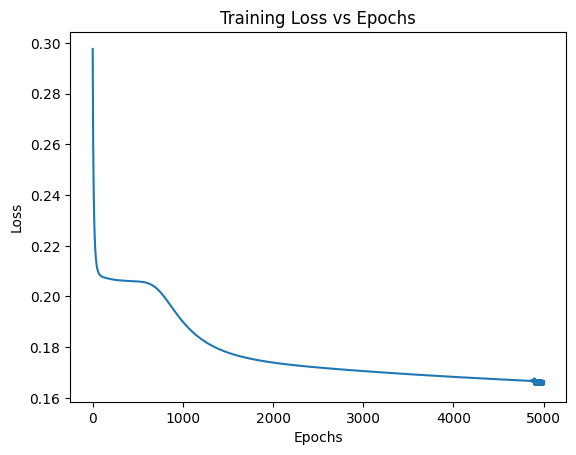

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=1)
y = y.reshape(-1,1)

# sigmoid
def sigmoid(x): return 1/(1+np.exp(-x))
def dsigmoid(x): return x*(1-x)

# initialize weights
np.random.seed(1)
w1 = np.random.randn(2,5)   # input -> hidden (5 neurons)
w2 = np.random.randn(5,1)   # hidden -> output

lr = 0.1
epochs = 5000
losses = []

# -------- Training --------
for i in range(epochs):

    # forward
    hidden = sigmoid(np.dot(X,w1))
    output = sigmoid(np.dot(hidden,w2))

    # error
    error = y - output
    losses.append(np.mean(np.abs(error)))

    # backward
    d_output = error * dsigmoid(output)
    d_hidden = np.dot(d_output,w2.T) * dsigmoid(hidden)

    # update
    w2 += np.dot(hidden.T,d_output)*lr
    w1 += np.dot(X.T,d_hidden)*lr

# -------- Predictions --------
pred = (output>0.5).astype(int)

print("Training Accuracy:", np.mean(pred==y))

# -------- Plot Loss --------
plt.plot(losses)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Exp 4 - Multi-Layer Perceptron

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9734 - loss: 0.0823

Total Test Accuracy: 0.9733999967575073
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


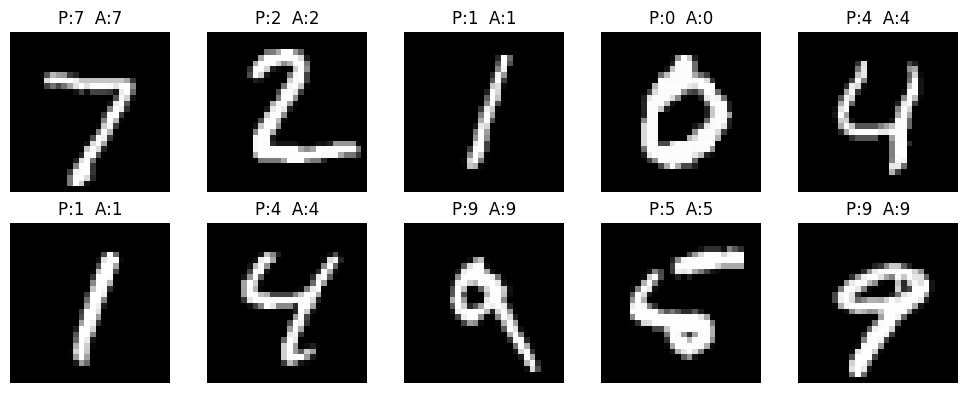

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------- Total Accuracy --------
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTotal Test Accuracy:", accuracy)

# -------- Predict --------
predictions = model.predict(X_test) 

# -------- Show digits --------
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')

    predicted = np.argmax(predictions[i])
    actual = y_test[i]

    plt.title(f"P:{predicted}  A:{actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Exp 5 - Activation Functions

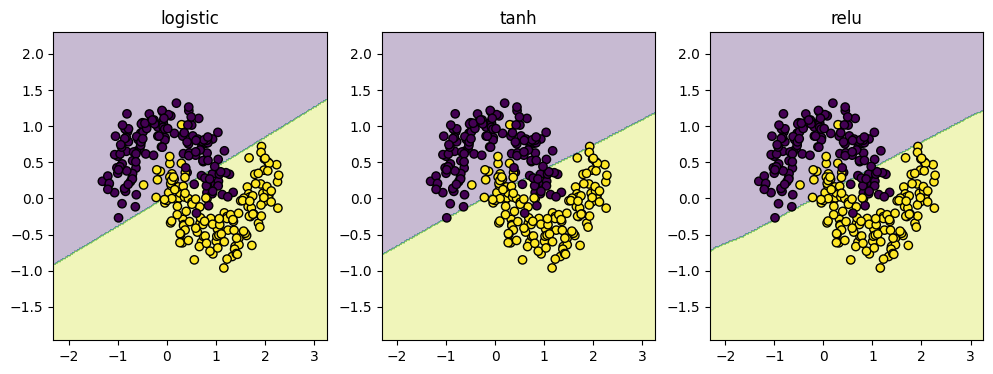

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier

# create dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=1)

# function to plot decision boundary
def plot_boundary(model, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min,x_max,h),
                         np.arange(y_min,y_max,h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title(title)

# different activation functions
activations = ['logistic','tanh','relu']

plt.figure(figsize=(12,4))

for i, act in enumerate(activations):
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=5000)
    model.fit(X,y)
    
    plt.subplot(1,3,i+1)
    plot_boundary(model, act)

plt.show()

Input shape: (300, 2)
Output shape: (300,)
First few targets: [1 1 1 0 1]


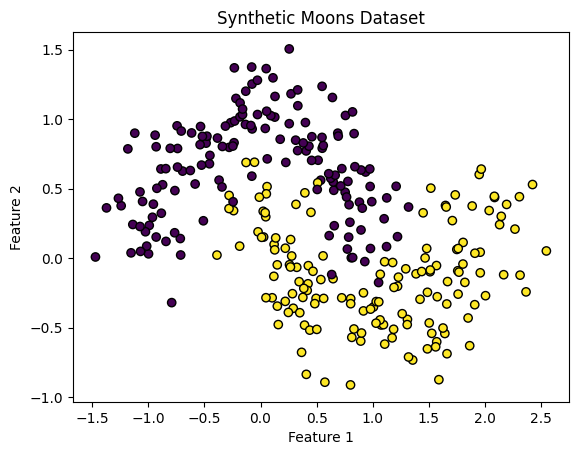

In [45]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate the dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Display dataset shape and first few samples
print(f"Input shape: {X.shape}")  # (300, 2)
print(f"Output shape: {y.shape}")  # (300,)
print(f"First few targets: {y[:5]}")  # [1 1 1 0 1]

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Moons Dataset')
plt.show()   